# Gas and Ridership Visualization

In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Reads fuel price data
gas_daily = pd.read_csv("../../data/02-processed/nyc_gas_prices_daily_2023.csv")
# Reads ridership data
ridership_daily = pd.read_csv("../../data/02-processed/daily_total_ridership.csv")
# Turn datasets into dataframe
gas_df = pd.DataFrame(gas_daily)
ridership_df = pd.DataFrame(ridership_daily)
gas_df.columns = ridership_df.columns.str.lower()
# Merge data
df = pd.merge(ridership_df, gas_df, on="date", how="inner")
df = df.rename(columns={
    "total_daily_trips_y": "gas_price",
    "total_daily_trips_x": "ridership"
})
df.head()

,date,ridership,gas_price
0,2023-01-02,479217,3.247
1,2023-01-03,573495,3.247
2,2023-01-04,599998,3.247
3,2023-01-05,629845,3.247
4,2023-01-06,721363,3.247


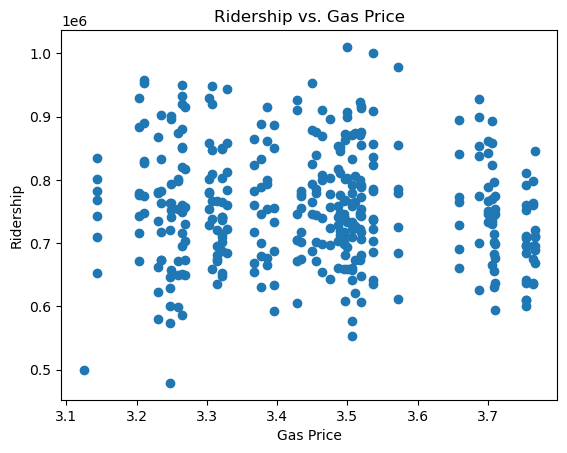

In [7]:
plt.scatter(df['gas_price'], df['ridership'])
plt.xlabel("Gas Price")
plt.ylabel("Ridership")
plt.title('Ridership vs. Gas Price')
plt.savefig('ridership_gas_price_scatter_plot.png')
plt.show()

In [8]:
# Correlation Factor
print(round(df['gas_price'].corr(df['ridership']), 3))

-0.086


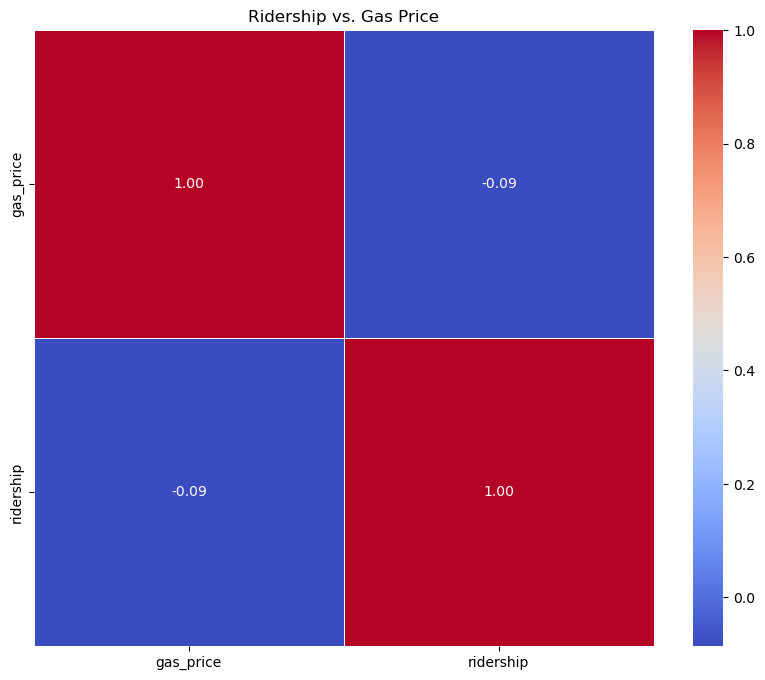

In [9]:
# Correlation Matrix
corr_matrix = df[['gas_price', 'ridership']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ridership vs. Gas Price')
plt.savefig('ridership_gas_price_correlation.png')
plt.show()